# NovaGen Research Labs — Health Risk Classification

## 1. Problem Understanding

NovaGen Research Labs is conducting large-scale population health studies to understand how underlying health conditions influence disease risk and long-term health outcomes.

The institute has collected health records from **9,800 individuals**, including a combination of **physiological measurements, lifestyle factors, and medical history attributes**.

The objective of this project is to build a **supervised machine learning classification model** that classifies individuals as either **healthy** or **unhealthy** based on their available health indicators.

The prediction can support:

- **Selecting eligible participants** for clinical trials and longitudinal studies
- **Stratifying populations** for risk-based analysis and outcome comparison

The dataset contains features such as **Age, BMI, Blood Pressure, Cholesterol, Glucose Level, Heart Rate, Sleep Hours, Exercise Hours, Water Intake, Stress Level, Smoking, Alcohol, Diet, Mental Health, Physical Activity, Medical History, Allergies, Diet Type, and Blood Group**.

The target variable, **`Target`**, represents the individual's health outcome or risk category.

# 2. Import Libraries

The following Python libraries are used for **data manipulation, visualization, preprocessing, model building, evaluation, and hyperparameter tuning**.

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-Test Split & Hyperparameter Tuning
from sklearn.model_selection import train_test_split, GridSearchCV

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# 3. Load data

In [2]:
df = pd.read_csv('novagen_dataset.csv')
df.head()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,False,True,True,False,False
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,2,2,False,False,True,False,False
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,True,False,False,False,False
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,2,0,True,False,False,True,False
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,False,True,False,True,False


# 4. Initial Data understanding

In [3]:
# Check the number of rows and columns
df.shape

(9549, 23)

In [4]:
# Get basic information about columns, data types, and non-null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9549 entries, 0 to 9548
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9549 non-null   float64
 1   BMI                    9549 non-null   float64
 2   Blood_Pressure         9549 non-null   float64
 3   Cholesterol            9549 non-null   float64
 4   Glucose_Level          9549 non-null   float64
 5   Heart_Rate             9549 non-null   float64
 6   Sleep_Hours            9549 non-null   float64
 7   Exercise_Hours         9549 non-null   float64
 8   Water_Intake           9549 non-null   float64
 9   Stress_Level           9549 non-null   float64
 10  Target                 9549 non-null   int64  
 11  Smoking                9549 non-null   int64  
 12  Alcohol                9549 non-null   int64  
 13  Diet                   9549 non-null   int64  
 14  MentalHealth           9549 non-null   int64  
 15  PhysicalActivit

In [5]:
# Generate descriptive statistics for numerical features
df.describe()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,Target,Smoking,Alcohol,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies
count,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000
mean,33.806786,25.660697,130.382658,199.091528,100.225678,73.613782,6.951409,1.892345,3.580899,4.382134,0.521416,0.990470,0.995183,1.005864,0.998429,1.003351,1.004713,0.989318
std,24.566473,1.942369,27.878476,1.969234,2.157999,1.681538,2.352152,1.378714,1.622874,2.078593,0.499567,0.815521,0.816653,0.815877,0.821844,0.808800,0.813506,0.815699
min,0.000000,19.000000,22.000000,192.000000,93.000000,67.000000,-0.000000,-0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,14.000000,24.000000,113.000000,198.000000,99.000000,73.000000,5.000000,1.000000,2.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,29.000000,26.000000,134.000000,199.000000,100.000000,74.000000,7.000000,2.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,50.000000,27.000000,150.000000,200.000000,102.000000,75.000000,9.000000,3.000000,5.000000,6.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,100.000000,32.000000,225.000000,207.000000,107.000000,80.000000,14.000000,8.000000,10.000000,12.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [6]:
# Check for missing values in each column
df.isnull().sum()

Age                      0
BMI                      0
Blood_Pressure           0
Cholesterol              0
Glucose_Level            0
Heart_Rate               0
Sleep_Hours              0
Exercise_Hours           0
Water_Intake             0
Stress_Level             0
Target                   0
Smoking                  0
Alcohol                  0
Diet                     0
MentalHealth             0
PhysicalActivity         0
MedicalHistory           0
Allergies                0
Diet_Type__Vegan         0
Diet_Type__Vegetarian    0
Blood_Group_AB           0
Blood_Group_B            0
Blood_Group_O            0
dtype: int64

# 5. EDA

### 5.1 Target Variable Distribution

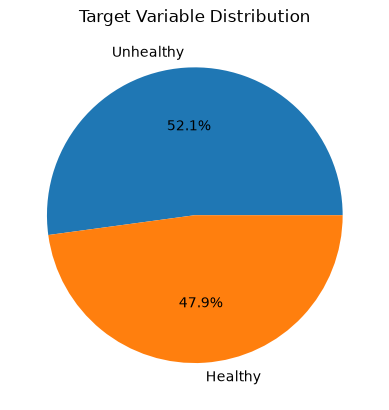

In [7]:
# how balanced our classes are?

classes_count = df["Target"].value_counts()

plt.pie(
    classes_count,
    labels=["Unhealthy", "Healthy"],
    autopct="%1.1f%%"
)

plt.title("Target Variable Distribution")
plt.show()

### 5.2 Age Distribution by Health Outcome

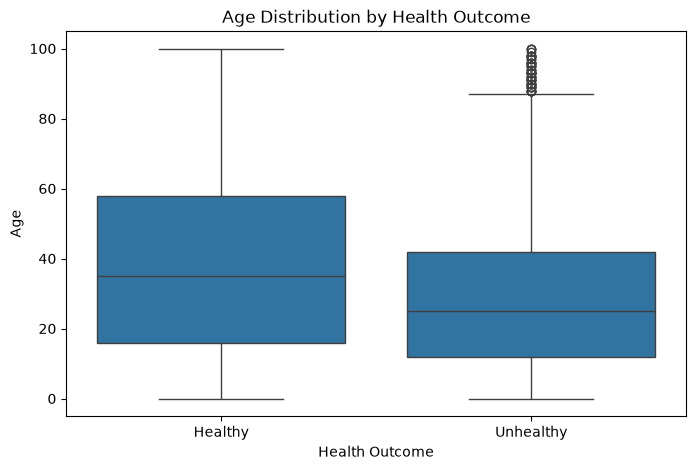

In [8]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Target",
    y="Age",
    data=df
)

plt.xticks([0, 1], ["Healthy", "Unhealthy"])
plt.title("Age Distribution by Health Outcome")
plt.xlabel("Health Outcome")
plt.ylabel("Age")

plt.show()

### 5.3 Key Health Indicators by Target

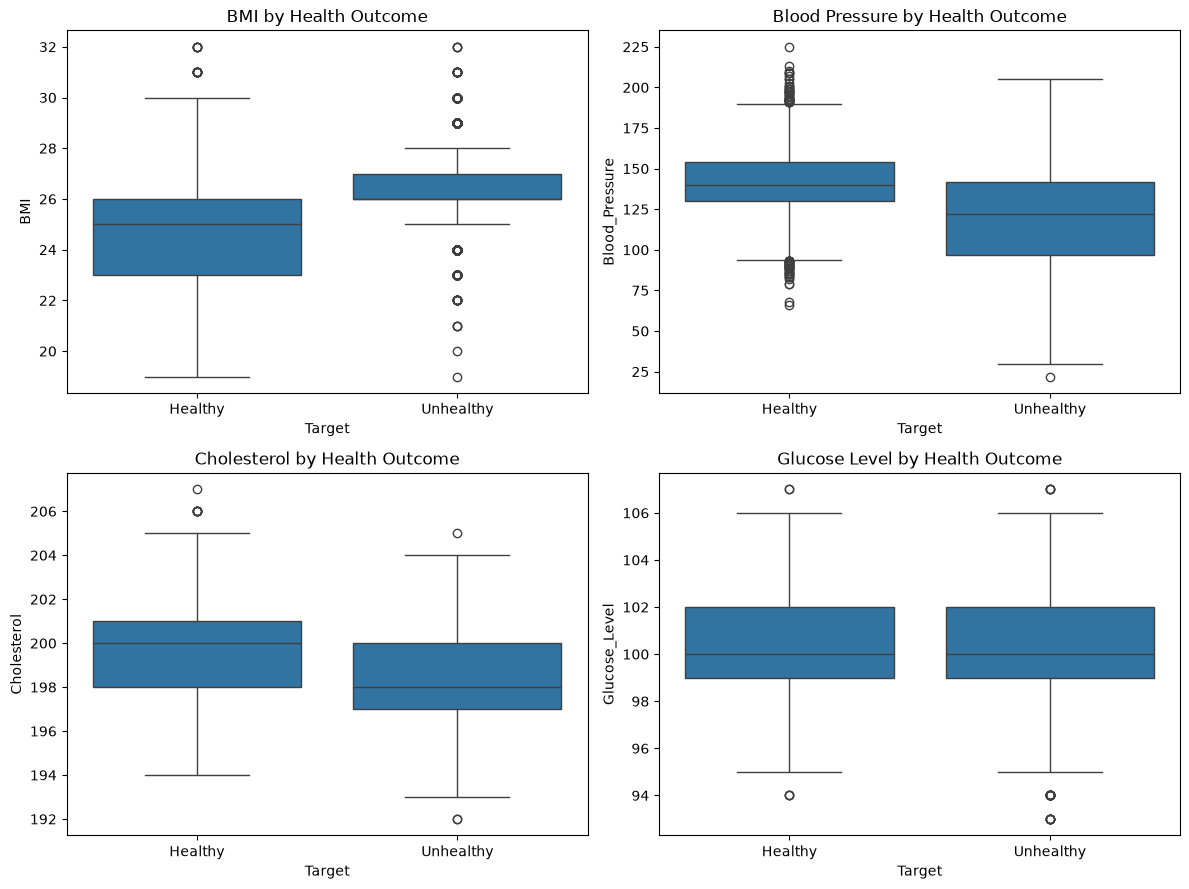

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.boxplot(x="Target", y="BMI", data=df, ax=axes[0, 0])
axes[0, 0].set_title("BMI by Health Outcome")
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(["Healthy", "Unhealthy"])

sns.boxplot(x="Target", y="Blood_Pressure", data=df, ax=axes[0, 1])
axes[0, 1].set_title("Blood Pressure by Health Outcome")
axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_xticklabels(["Healthy", "Unhealthy"])

sns.boxplot(x="Target", y="Cholesterol", data=df, ax=axes[1, 0])
axes[1, 0].set_title("Cholesterol by Health Outcome")
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_xticklabels(["Healthy", "Unhealthy"])

sns.boxplot(x="Target", y="Glucose_Level", data=df, ax=axes[1, 1])
axes[1, 1].set_title("Glucose Level by Health Outcome")
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(["Healthy", "Unhealthy"])

plt.tight_layout()
plt.show()

###  5.4 Lifestyle Factors vs Health Outcome

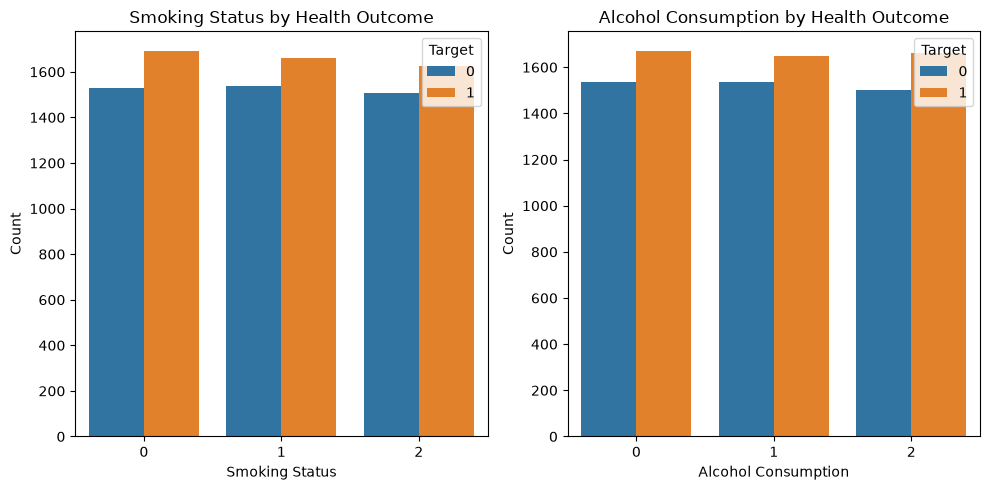

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.countplot(x="Smoking", hue="Target", data=df, ax=axes[0])
axes[0].set_title("Smoking Status by Health Outcome")
axes[0].set_xlabel("Smoking Status")
axes[0].set_ylabel("Count")

sns.countplot(x="Alcohol", hue="Target", data=df, ax=axes[1])
axes[1].set_title("Alcohol Consumption by Health Outcome")
axes[1].set_xlabel("Alcohol Consumption")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

### 5.5 Exercise and Sleep vs Health Outcome

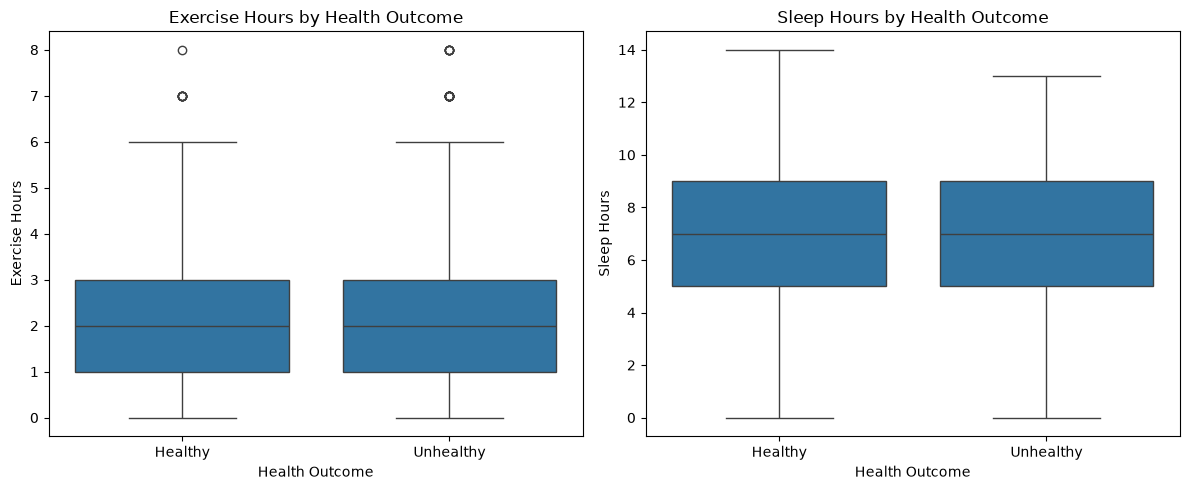

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x="Target", y="Exercise_Hours", data=df, ax=axes[0])
axes[0].set_title("Exercise Hours by Health Outcome")
axes[0].set_xlabel("Health Outcome")
axes[0].set_ylabel("Exercise Hours")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Healthy", "Unhealthy"])

sns.boxplot(x="Target", y="Sleep_Hours", data=df, ax=axes[1])
axes[1].set_title("Sleep Hours by Health Outcome")
axes[1].set_xlabel("Health Outcome")
axes[1].set_ylabel("Sleep Hours")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Healthy", "Unhealthy"])

plt.tight_layout()
plt.show()

### 5.6 Correlation Heatmap

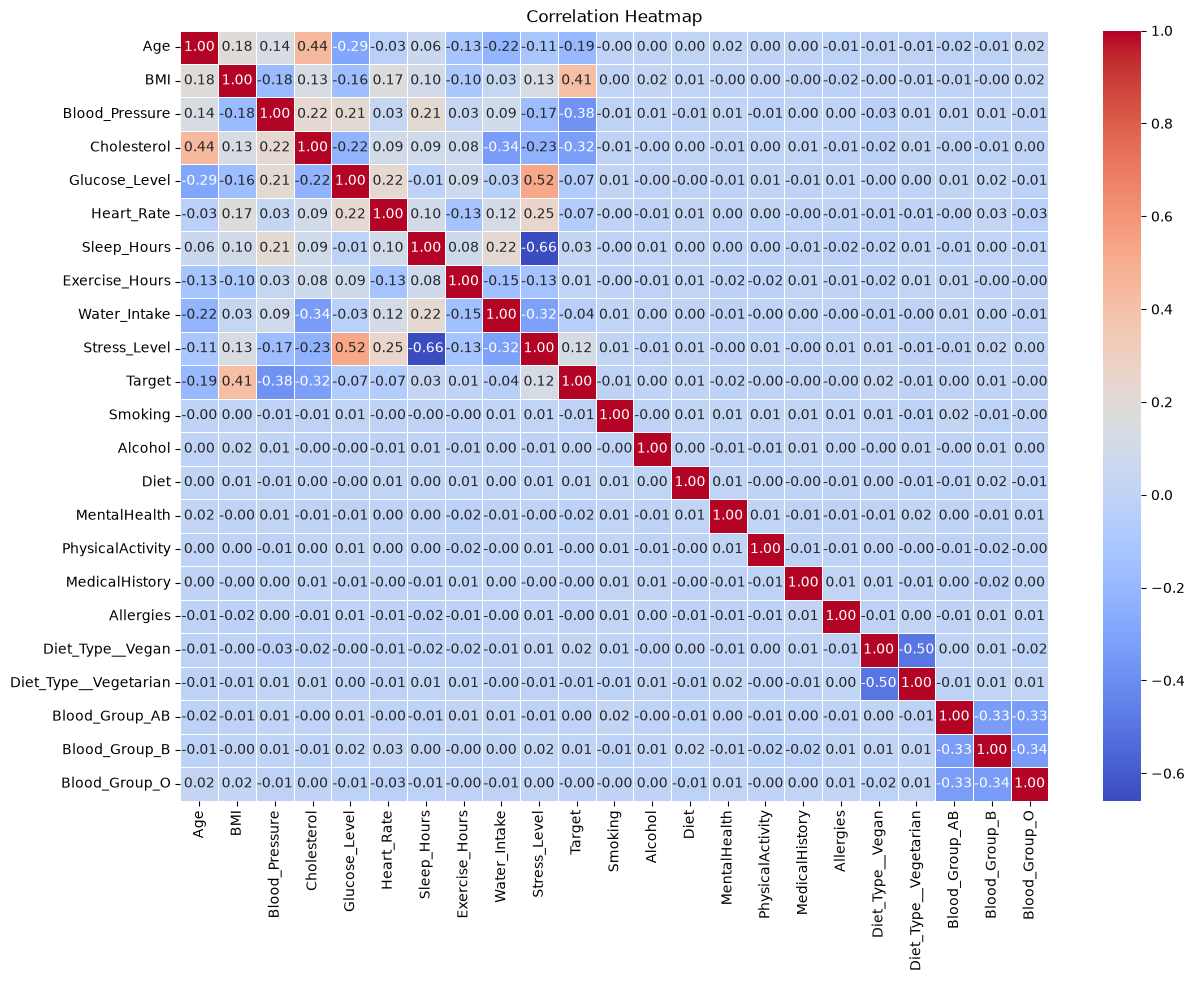

In [12]:
plt.figure(figsize=(14, 10))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

# 6. Separate Features & target

In [13]:
df["Target"] = df["Target"].astype(int)

In [14]:
X = df.drop("Target", axis=1)
y = df["Target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (9549, 22)
Target shape: (9549,)


# 7. Train-Test-Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (7639, 22)
X_test shape: (1910, 22)
y_train shape: (7639,)
y_test shape: (1910,)


# 8. Feature Preprocessing

In [16]:
# Check data types of the feature columns
X_train.dtypes

Age                      float64
BMI                      float64
Blood_Pressure           float64
Cholesterol              float64
Glucose_Level            float64
Heart_Rate               float64
Sleep_Hours              float64
Exercise_Hours           float64
Water_Intake             float64
Stress_Level             float64
Smoking                    int64
Alcohol                    int64
Diet                       int64
MentalHealth               int64
PhysicalActivity           int64
MedicalHistory             int64
Allergies                  int64
Diet_Type__Vegan            bool
Diet_Type__Vegetarian       bool
Blood_Group_AB              bool
Blood_Group_B               bool
Blood_Group_O               bool
dtype: object

In [17]:
# Separate numerical and boolean features

numeric_features = X.select_dtypes(include=["number", "bool"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features)
    ],
    remainder="drop"
)

# 9. Build the model pipeline

In [18]:
# logistic regression pipeline

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

In [19]:
# k-nearest neighbors pipeline

knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

In [20]:
# random forest pipeline

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

In [21]:
# adaBoost pipeline

base_tree = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

adaboost_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", AdaBoostClassifier(
        estimator=base_tree,
        n_estimators=100,
        random_state=42
    ))
])

In [22]:
lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['Age','BMI','Blood_Pressure',...,'Blood_Group_AB','Blood_Group_B', 'Blood_Group_O']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all r

In [23]:
knn_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['Age','BMI','Blood_Pressure',...,'Blood_Group_AB','Blood_Group_B', 'Blood_Group_O']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all r

In [24]:
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['Age','BMI','Blood_Pressure',...,'Blood_Group_AB','Blood_Group_B', 'Blood_Group_O']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all r

In [25]:
adaboost_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['Age','BMI','Blood_Pressure',...,'Blood_Group_AB','Blood_Group_B', 'Blood_Group_O']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all r

# 10. Evaluate

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

models = {
    "Logistic Regression": lr_pipeline,
    "KNN": knn_pipeline,
    "Random Forest": rf_pipeline,
    "AdaBoost": adaboost_pipeline
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.81      0.80      0.80       914
           1       0.82      0.83      0.82       996

    accuracy                           0.81      1910
   macro avg       0.81      0.81      0.81      1910
weighted avg       0.81      0.81      0.81      1910


KNN
              precision    recall  f1-score   support

           0       0.87      0.88      0.88       914
           1       0.89      0.88      0.89       996

    accuracy                           0.88      1910
   macro avg       0.88      0.88      0.88      1910
weighted avg       0.88      0.88      0.88      1910


Random Forest
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       914
           1       0.93      0.96      0.94       996

    accuracy                           0.94      1910
   macro avg       0.94      0.94      0.94      1910
weighted avg       0.94      0.94

In [27]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.813613,0.817460,0.827309,0.822355
1,KNN,0.883246,0.891591,0.883534,0.887544
2,Random Forest,0.939791,0.925604,0.961847,0.943378
3,AdaBoost,0.836126,0.844601,0.840361,0.842476


In [28]:
results_df[["Accuracy", "Precision", "Recall", "F1 Score"]] = (
    results_df[["Accuracy", "Precision", "Recall", "F1 Score"]] * 100
).round(2)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,81.36,81.75,82.73,82.24
1,KNN,88.32,89.16,88.35,88.75
2,Random Forest,93.98,92.56,96.18,94.34
3,AdaBoost,83.61,84.46,84.04,84.25


# 11. Hyperparameter Tuning & Pruning

Hyperparameter tuning is performed using **GridSearchCV with 5-fold cross-validation** and **F1-score** as the scoring metric.

The following hyperparameters were selected because they directly control model complexity, learning behaviour, or prediction strategy:

- **Random Forest:** `n_estimators`, `max_depth`, `min_samples_split`, and `min_samples_leaf`
- **KNN:** `n_neighbors`, `weights`, and `metric`
- **AdaBoost:** `n_estimators` and `learning_rate`
- **Logistic Regression:** `C`

Only relevant hyperparameters were included in each search to balance model optimization with computational cost.

In [29]:
rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best CV F1:", rf_grid.best_score_)

Best Parameters: {'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV F1: 0.9401044315452219


In [30]:
knn_param_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 13, 15, 17],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

knn_grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

print("Best Parameters:", knn_grid.best_params_)
print("Best CV F1:", knn_grid.best_score_)

Best Parameters: {'model__metric': 'manhattan', 'model__n_neighbors': 15, 'model__weights': 'distance'}
Best CV F1: 0.9000311178027429


In [31]:
adaboost_param_grid = {
    "model__n_estimators": [50, 100, 200, 300, 400],
    "model__learning_rate": [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
}

adaboost_grid = GridSearchCV(
    estimator=adaboost_pipeline,
    param_grid=adaboost_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

adaboost_grid.fit(X_train, y_train)

print("Best Parameters:", adaboost_grid.best_params_)
print("Best CV F1:", adaboost_grid.best_score_)

Best Parameters: {'model__learning_rate': 0.5, 'model__n_estimators': 400}
Best CV F1: 0.8492017606124203


## 12. Evaluate Tuned & Pruned Model

In [32]:
best_rf = rf_grid.best_estimator_
best_knn = knn_grid.best_estimator_
best_adaboost = adaboost_grid.best_estimator_
best_lr = lr_pipeline

In [33]:
tuned_models = {
    "Logistic Regression": best_lr,
    "KNN": best_knn,
    "Random Forest": best_rf,
    "AdaBoost": best_adaboost
}

tuned_results = []

for name, model in tuned_models.items():
    y_pred = model.predict(X_test)

    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.813613,0.817460,0.827309,0.822355
1,KNN,0.903665,0.898039,0.919679,0.908730
2,Random Forest,0.938743,0.923819,0.961847,0.942450
3,AdaBoost,0.841885,0.851927,0.843373,0.847629


## 13. Model Comparison

The baseline and tuned models are compared using **Accuracy, Precision, Recall, and F1-score**.

The comparison helps determine whether hyperparameter tuning improved each model's performance and identifies the strongest individual model before building the final Voting ensemble.

In [34]:
comparison_df = pd.DataFrame({
    "Model": results_df["Model"],
    "Baseline F1": results_df["F1 Score"],
    "Tuned F1": tuned_results_df["F1 Score"] * 100
})

comparison_df["Improvement"] = (
    comparison_df["Tuned F1"] - comparison_df["Baseline F1"]
).round(2)

comparison_df

,Model,Baseline F1,Tuned F1,Improvement
0,Logistic Regression,82.24,82.235529,-0.00
1,KNN,88.75,90.873016,2.12
2,Random Forest,94.34,94.244958,-0.10
3,AdaBoost,84.25,84.762866,0.51


## 14. Voting classifier

In [35]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[
        ("rf", best_rf),
        ("knn", best_knn),
        ("ada", best_adaboost)
    ],
    voting="soft"
)

voting_clf.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('rf', ...), ('knn', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[Pipeline(step...m_state=42))]), Pipeline(step...'distance'))]), Pipeline(step...m_state=42))])]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['Age','BMI','Blood_Pressure',...,'Blood_Group_AB','Blood_Group_B', 'Blood_Group_O']"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()


In [36]:
y_pred_voting = voting_clf.predict(X_test)

In [37]:
voting_accuracy = accuracy_score(y_test, y_pred_voting)
voting_precision = precision_score(y_test, y_pred_voting)
voting_recall = recall_score(y_test, y_pred_voting)
voting_f1 = f1_score(y_test, y_pred_voting)

print("Voting Classifier")
print("Accuracy :", voting_accuracy)
print("Precision:", voting_precision)
print("Recall   :", voting_recall)
print("F1 Score :", voting_f1)

Voting Classifier
Accuracy : 0.9267015706806283
Precision: 0.9171539961013645
Recall   : 0.9447791164658634
F1 Score : 0.9307616221562809


# 15. Final Model Comparison

In [38]:
final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Random Forest",
        "AdaBoost",
        "Voting Classifier"
    ],
    "F1 Score": [
        results_df.loc[results_df["Model"] == "Logistic Regression", "F1 Score"].iloc[0],
        tuned_results_df.loc[tuned_results_df["Model"] == "KNN", "F1 Score"].iloc[0] * 100,
        tuned_results_df.loc[tuned_results_df["Model"] == "Random Forest", "F1 Score"].iloc[0] * 100,
        tuned_results_df.loc[tuned_results_df["Model"] == "AdaBoost", "F1 Score"].iloc[0] * 100,
        voting_f1 * 100
    ]
})

final_comparison["F1 Score"] = final_comparison["F1 Score"].round(2)

final_comparison

,Model,F1 Score
0,Logistic Regression,82.24
1,KNN,90.87
2,Random Forest,94.24
3,AdaBoost,84.76
4,Voting Classifier,93.08


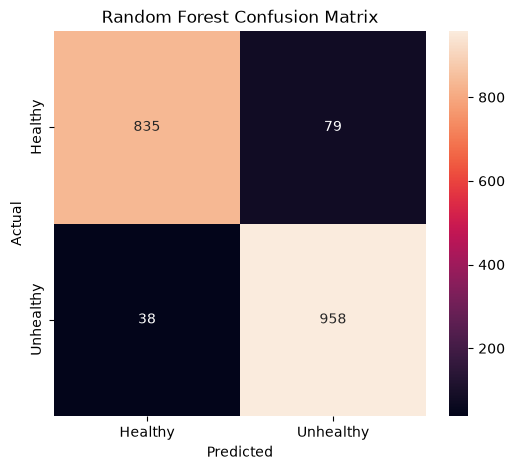

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_rf = best_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Healthy", "Unhealthy"],
    yticklabels=["Healthy", "Unhealthy"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

# 16. Conclusion

The objective of this project was to classify individuals as **healthy or unhealthy** using demographic, physiological, lifestyle, and medical-history features.

Four classification models were evaluated: **Logistic Regression, KNN, Random Forest, and AdaBoost**. Among the baseline models, **Random Forest** achieved the highest F1-score of **94.34%**.

Hyperparameter tuning improved the performance of **KNN from 88.75% to 90.87%** and **AdaBoost from 84.25% to 84.76%**. Random Forest remained almost unchanged, achieving a tuned F1-score of **94.25%**, showing that its baseline configuration was already highly effective.

A **Soft Voting Classifier** combining the tuned Random Forest, KNN, and AdaBoost models was also evaluated. It achieved an F1-score of **93.08%**, which was lower than the tuned Random Forest.

Therefore, **Random Forest was selected as the final model**, achieving the highest F1-score of **94.25%** and a recall of **96.18%** on the test set.